In [66]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [67]:
import pandas as pd

df = pd.read_csv("ridepulse_lstm_dataset_2000_rows.csv")

print(df.head())
print(df.shape)

           datetime  hour  day_of_week  is_weekend  route_id  location  \
0  2026-01-01 00:00     0            3           0       101  Dehiwala   
1  2026-01-01 01:00     1            3           0       120   Negombo   
2  2026-01-01 02:00     2            3           0       101  Dehiwala   
3  2026-01-01 03:00     3            3           0       101   Colombo   
4  2026-01-01 04:00     4            3           0       100   Negombo   

  weather  rain traffic_level  is_holiday  previous_passenger_count  \
0   Clear     0           Low           0                       100   
1   Clear     0           Low           0                        44   
2    Rain     1           Low           1                        49   
3  Cloudy     0           Low           0                        53   
4   Clear     0           Low           0                        72   

   passenger_count  
0               44  
1               49  
2               53  
3               72  
4               63  
(2

In [68]:
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

In [69]:
df['lag_1'] = df['passenger_count'].shift(1)
df['lag_2'] = df['passenger_count'].shift(2)
df['lag_3'] = df['passenger_count'].shift(3)

In [109]:
df['rolling_mean_3'] = df['passenger_count'].shift(1).rolling(3).mean()
df['rolling_mean_5'] = df['passenger_count'].shift(1).rolling(5).mean()

In [110]:
df['passenger_count'] = df['passenger_count'] + np.random.normal(0, 5, len(df))

In [111]:
def is_peak(hour):
    return 1 if (6 <= hour <= 9 or 16 <= hour <= 19) else 0

df['is_peak_hour'] = df['hour'].apply(is_peak)

In [112]:
df['rain_peak'] = df['rain'] * df['is_peak_hour']

In [113]:
df = df.dropna()

In [114]:
le = LabelEncoder()

df['route_id'] = le.fit_transform(df['route_id'])
df['location'] = le.fit_transform(df['location'])
df['weather'] = le.fit_transform(df['weather'])
df['traffic_level'] = le.fit_transform(df['traffic_level'])

In [115]:
features = [
    'hour','day_of_week','is_weekend',
    'route_id','location','weather','rain',
    'traffic_level','is_holiday',
    'lag_1','lag_2','lag_3',
    'rolling_mean_3','rolling_mean_5',
    'is_peak_hour','rain_peak'
]

In [116]:
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

y_scaler = MinMaxScaler()
df['passenger_count'] = y_scaler.fit_transform(df[['passenger_count']])


In [117]:
sequence_length = 20

X = []
y = []

for i in range(len(df) - sequence_length):
    X.append(df[features].iloc[i:i+sequence_length].values)
    y.append(df['passenger_count'].iloc[i+sequence_length])

X = np.array(X)
y = np.array(y)

In [118]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [119]:

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/opt/miniconda3/envs/cnn-assignment/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [120]:
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0502 - val_loss: 0.0265
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0301 - val_loss: 0.0245
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0302 - val_loss: 0.0230
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0297 - val_loss: 0.0230
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0280 - val_loss: 0.0242
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0280 - val_loss: 0.0247
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0269 - val_loss: 0.0274
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0269 - val_loss: 0.0266
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0275 - val_loss: 0.0242
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0271 - val_loss: 0.0240
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0268 - val_loss: 0.0246
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0

In [121]:
y_pred = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [122]:
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_actual = y_scaler.inverse_transform(y_pred)

In [140]:
train_values = y_scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

threshold = np.quantile(train_values, 0.65)

In [141]:
def classify_binary(x):
    return 0 if x < threshold else 1

y_test_class = [classify_binary(x[0]) for x in y_test_actual]
y_pred_class = [classify_binary(x[0]) for x in y_pred_actual]

In [142]:

print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("Precision:", precision_score(y_test_class, y_pred_class, average='weighted'))
print("Recall:", recall_score(y_test_class, y_pred_class, average='weighted'))
print("F1 Score:", f1_score(y_test_class, y_pred_class, average='weighted'))

Accuracy: 0.6658227848101266
Precision: 0.44331998077231216
Recall: 0.6658227848101266
F1 Score: 0.5322534723558154


/opt/miniconda3/envs/cnn-assignment/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))

MAE: 4.023822840193904
RMSE: 5.074084435321666


In [139]:
import numpy as np

print(np.percentile(train_values, [0, 25, 50, 75, 100]))

[-16.89574161  -3.09145346   0.70573774   4.19285802  15.72165766]


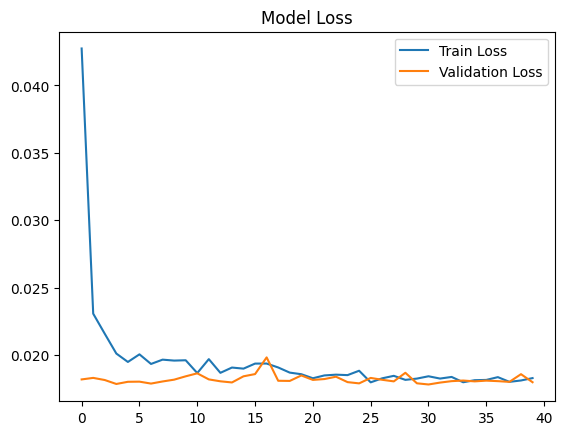

In [137]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

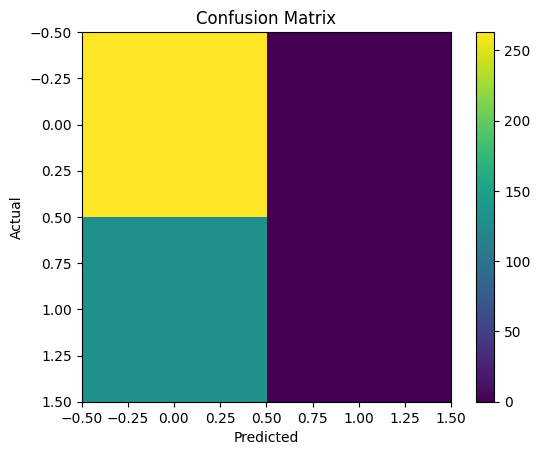

In [143]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_class, y_pred_class)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [144]:
model.save("lstm_crowd_model.h5")